# SSA Pipeline (ver.1)

## Phase 1

1. Create Hankel matrix of the segment of the signal
2. Apply SVD on the Hankel matrix
3. Select the appropriate number of singular components using singual value variance (>95%)
4. Reconstruct the extracted segment of the signal (mECG)

## Phase 2

5. Find peaks and remove them from mECG (Note: at this point, overlapping peaks with fECG will disappear)
6. Repeat the procedure from Phase 1 to extract the second ECG (fECG)

In [3]:
from scipy.linalg import hankel, svd
from tensorly.decomposition import tucker

import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
import tensorly as tl

import os, wget
import pyedflib

In [11]:
# # Run this cell only if you need to download the dataset
# !cd .. && mkdir data\raw && cd data\raw
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r01.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r04.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r07.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r08.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r10.edf

In [4]:
# please run EdfReader only once otherwise it will throw an error
edf_path = os.path.join("..", "data", "raw", "r01.edf")

try:
    edf = pyedflib.EdfReader(edf_path)
except:
    edf._close()
    del edf
    edf = pyedflib.EdfReader(edf_path)

In [5]:

# useful functions
def get_signal_segment(ch_number: int = 0, start_time: float = 0, end_time: float = 5):
    sampling_rate = edf.getSampleFrequency(ch_number)
    signal = edf.readSignal(ch_number)
    onsets, _, _ = edf.readAnnotations()
    
    start_index = int(start_time * sampling_rate)
    end_index = int(end_time * sampling_rate)
    
    if start_index < 0 or end_index > len(signal):
        raise ValueError("Start time or end time is out of signal bounds.")
    signal_segment = signal[start_index:end_index]
    time_segment = np.linspace(start_time, end_time, len(signal_segment))
    
    onsets_in_segment = onsets[(onsets >= start_time) & (onsets <= end_time)]
    onset_values = np.interp(onsets_in_segment, time_segment, signal_segment)
    
    return signal_segment, time_segment, onsets_in_segment, onset_values

def plot_signal(
    signal: np.ndarray,
    time: np.ndarray,
    onsets: np.ndarray = None,
    onsets_values: np.ndarray = None,
    title: str = "ECG Signal Segment",
    xlabel: str = "Time (s)",
    ylabel: str = "Amplitude (µV)",
    figsize: tuple = (15, 5),
    filename: str = None
):
    plt.figure(figsize=figsize)
    plt.plot(time, signal, label="ECG Signal")
    
    if onsets is not None and onsets_values is not None:
        plt.scatter(onsets, onsets_values, color="red", label="R-peaks", zorder=5)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid()
    
    if filename:
        plt.savefig(filename)
    plt.show()
    
def hankelize_and_extract(signal, window_size: int = 625*2, cvp: int = 75) -> np.ndarray:
    # create the Hankel matrix of the given signal
    L = window_size
    H = hankel(signal[:L], signal[L-1:])
    
    # perform SVD on the Hankel matrix
    U, S, VT = svd(H, full_matrices=False)
    
    # calculate explained variances and determine number of components to retain
    variances = S**2 / (H.shape[0]-1)
    explained_variances = variances / np.sum(variances)
    cumulative_variance_percentage = np.cumsum(explained_variances) * 100
    
    n_components = np.argmax(cumulative_variance_percentage >= cvp) + 1

    # reconstruct the signal using the selected number of components
    R = U[:, 0:n_components] @ np.diag(S[0:n_components]) @ VT[0:n_components, :]

    L = R.shape[0]
    K = R.shape[1]
    M = L + K - 1

    # initialize the reconstructed signal array
    extracted_signal = np.zeros(M)
    count = np.zeros(M) # array to keep track of how many elements contributed to the average

    # iterate through every element of the reconstructed matrix R
    for i in range(L):
        for j in range(K):
            # the anti-diagonal index (m) is i + j
            m = i + j
            
            # accumulate the value and the count for this anti-diagonal
            extracted_signal[m] += R[i, j]
            count[m] += 1

    # divide the accumulated sum by the count to get the average
    extracted_signal /= count
    
    return extracted_signal


def interpolate_peaks(signal: np.ndarray, sampling_rate: int = 1000, peaks: np.ndarray = [], show: bool = False) -> np.ndarray:
    _, info = nk.ecg_peaks(-signal, sampling_rate=sampling_rate, correct_artifacts=True)
    
    clean_signal = signal.copy()
    for i in range(len(peaks)):
        # "ammorbidisce" il segnale intorno al picco
        clean_signal[peaks[i]-70:peaks[i]+70] = signal[peaks[i]-70:peaks[i]+70] * 0.1
    if show:
        plt.figure(figsize=(15, 5))
        plt.plot(clean_signal, color='grey', alpha=0.7)
        plt.plot(signal, color='orange', alpha=0.3)
    
    return clean_signal

def analyze_signal_quality(signal: np.ndarray, sampling_rate: int = 1000, cvp_values: list = [70, 75, 80, 85, 90, 95], window_size: int = 625*2) -> tuple:
    cvps = []
    for cvp in cvp_values:
        # print("Creating Hankel matrix with CVP =", cvp)
        cvps.append(hankelize_and_extract(signal, window_size=window_size, cvp=cvp))
        
    signals_quality = []
    for s in cvps:    
        s_quality = nk.ecg_quality(s, sampling_rate=sampling_rate)
        signals_quality.append(s_quality.mean())
        
    best_signal = cvps[np.argmax(signals_quality)]
    
    return cvp_values[np.argmax(signals_quality)], best_signal, signals_quality

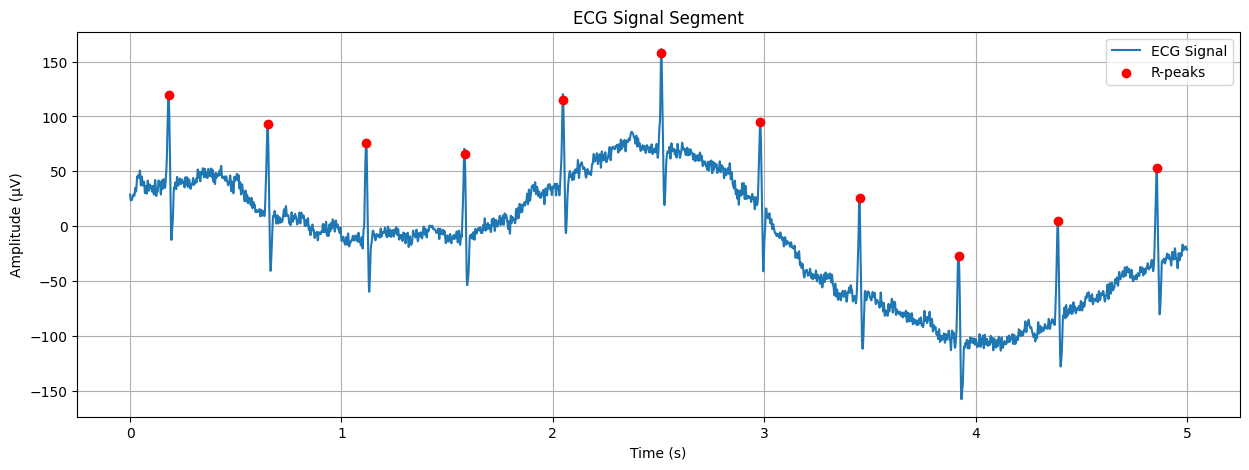

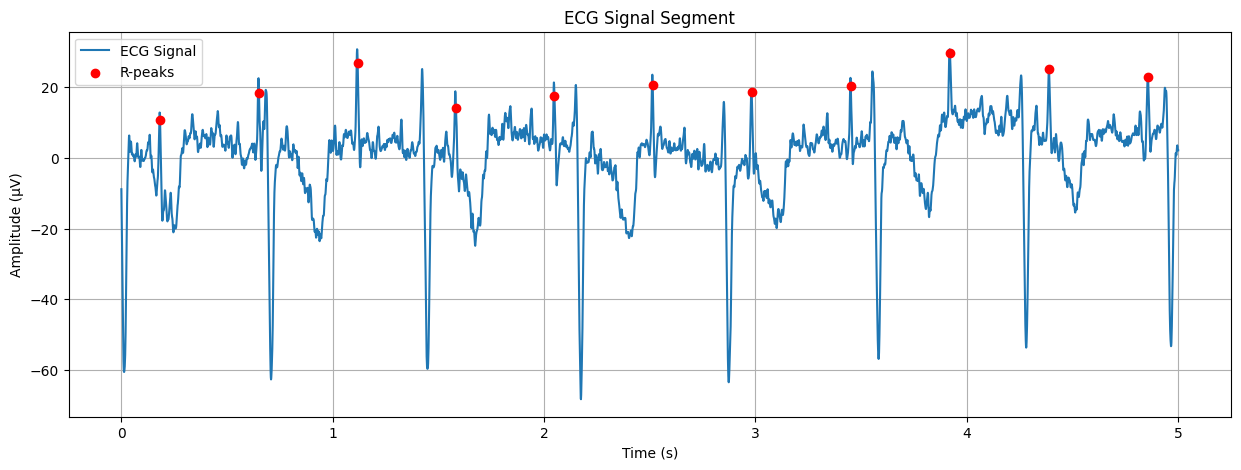

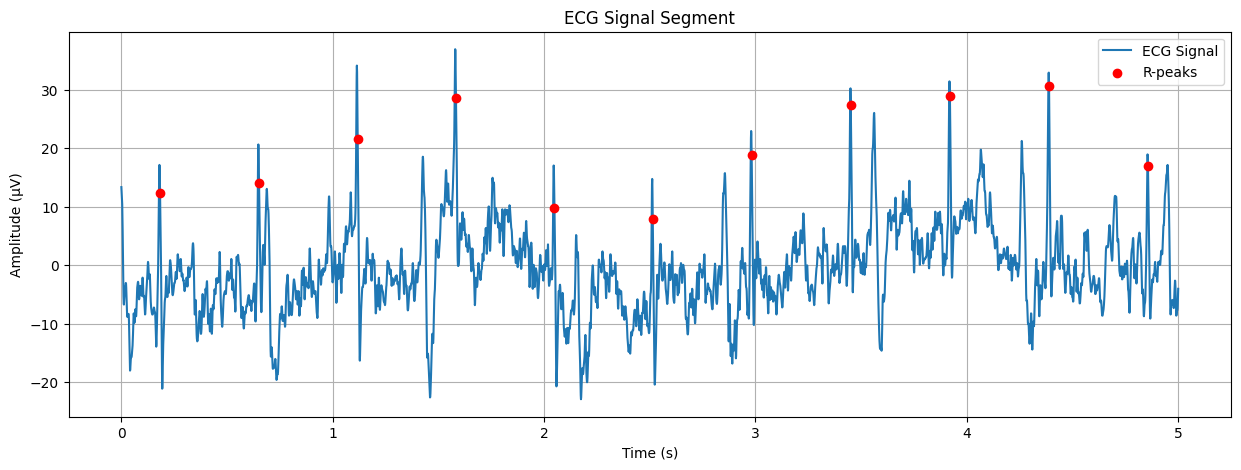

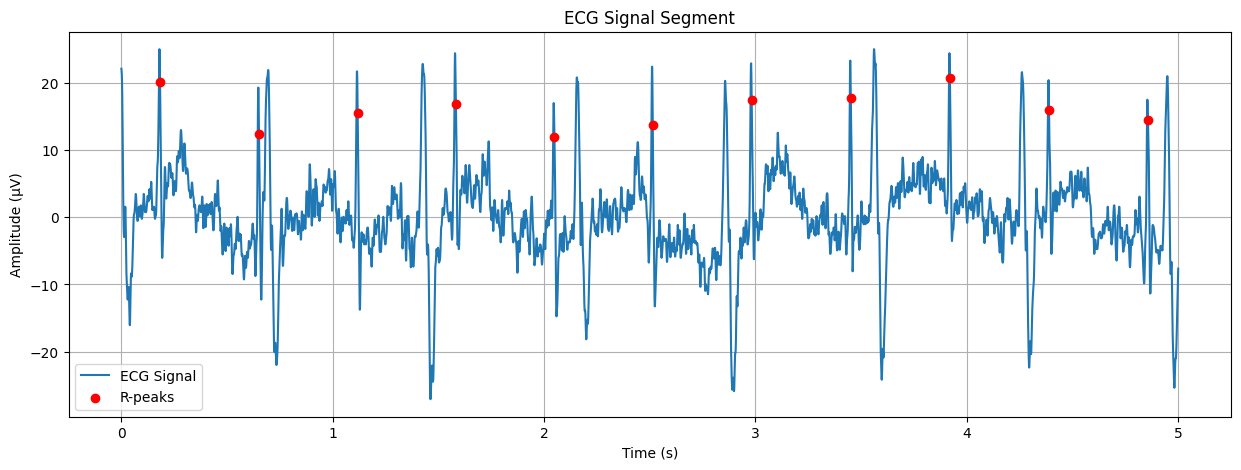

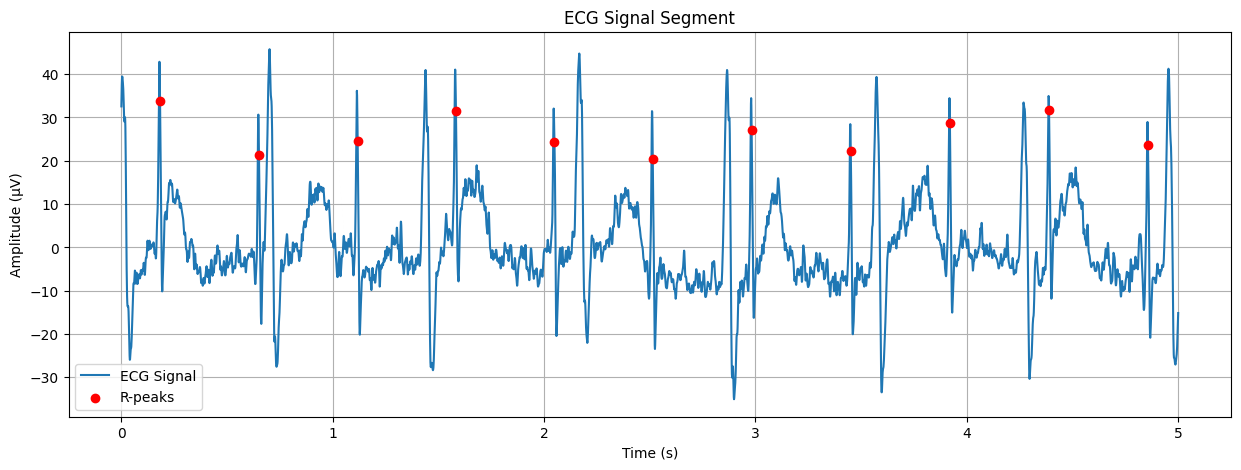

In [14]:
direct_segment, time_segment, onsets, onsets_values = get_signal_segment(ch_number=0)
abdomen_segment_1, time_segment_1, onsets_1, onsets_values_1 = get_signal_segment(ch_number=1)
abdomen_segment_2, time_segment_2, onsets_2, onsets_values_2 = get_signal_segment(ch_number=2)
abdomen_segment_3, time_segment_3, onsets_3, onsets_values_3 = get_signal_segment(ch_number=3)
abdomen_segment_4, time_segment_4, onsets_4, onsets_values_4 = get_signal_segment(ch_number=4)

plot_signal(direct_segment, time_segment, onsets, onsets_values)
plot_signal(abdomen_segment_1, time_segment_1, onsets_1, onsets_values_1)
plot_signal(abdomen_segment_2, time_segment_2, onsets_2, onsets_values_2)
plot_signal(abdomen_segment_3, time_segment_3, onsets_3, onsets_values_3)
plot_signal(abdomen_segment_4, time_segment_4, onsets_4, onsets_values_4)

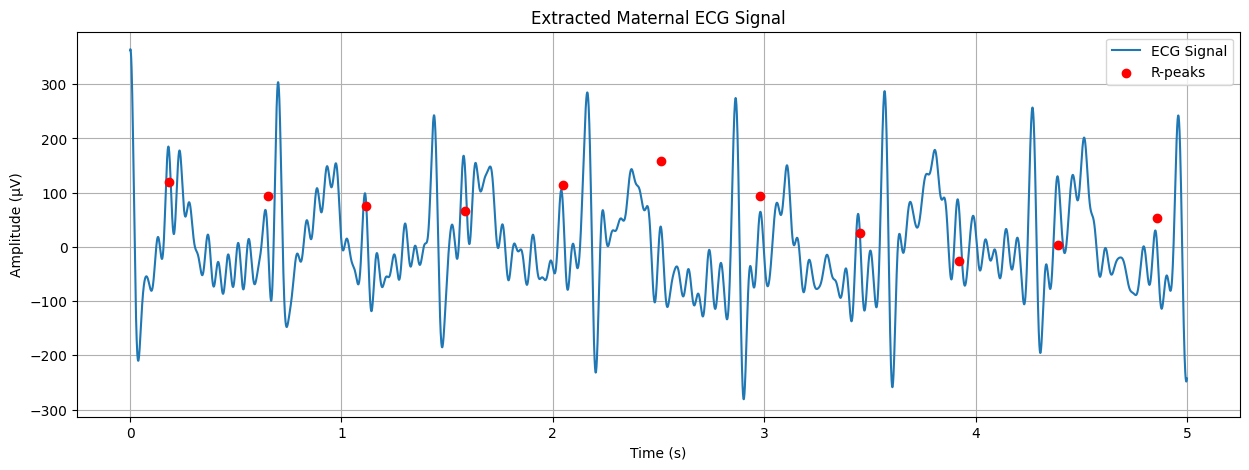

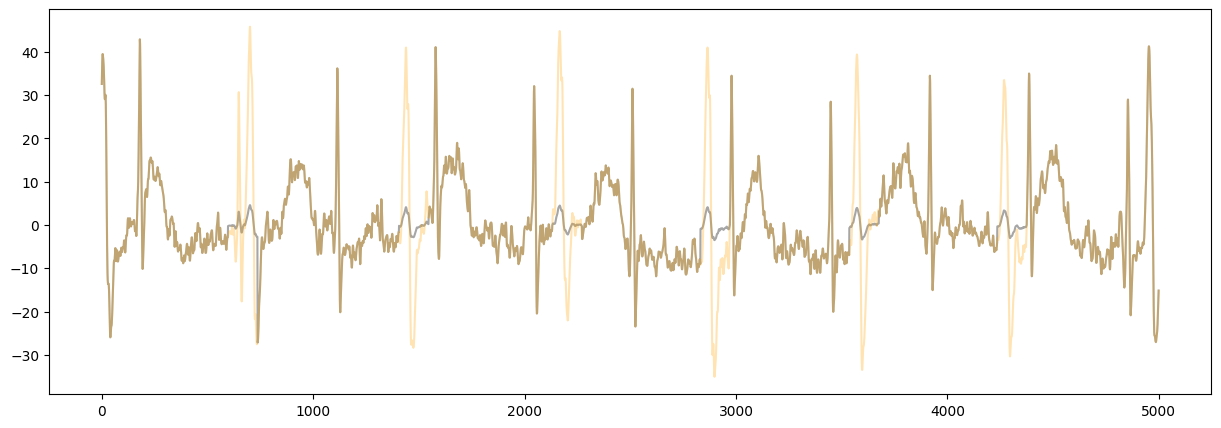

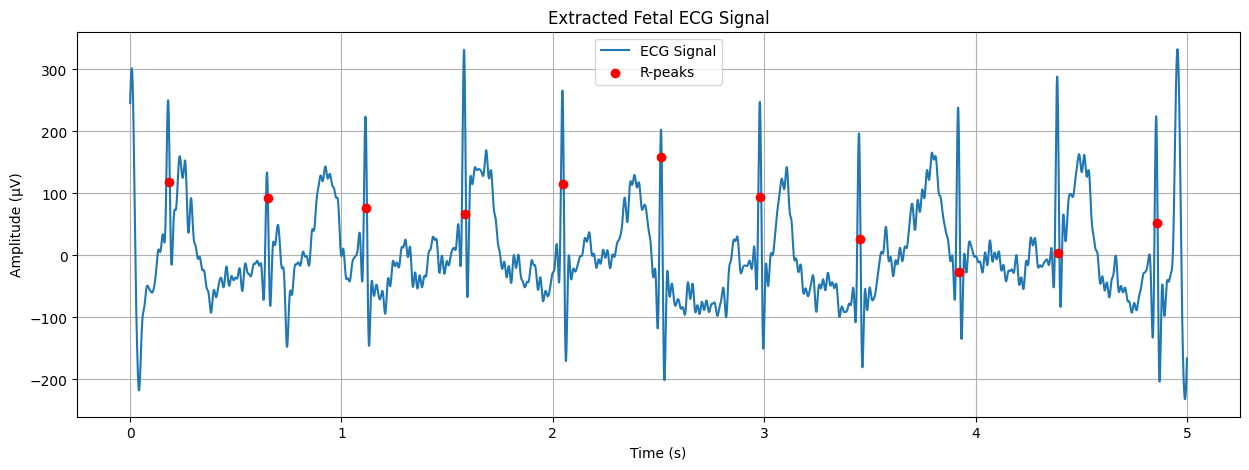

In [15]:
# This signal has 8 beats in 5 seconds for the mother and 15 beats for the fetus
# 8/5 = 1.6 -> 1/1.6 = 0.625 -> 0.625 * 1000 = 625 samples
# 11/5 = 2.2 -> 1/2.2 = 0.454 -> 0.454 * 1000 = 454 samples

mecg = hankelize_and_extract(abdomen_segment_4, window_size=625*2, cvp=70)
mecg_signals, mecg_info = nk.ecg_peaks(-mecg, sampling_rate=1000, correct_artifacts=True, method="emrich2023")
plot_signal(mecg*10, np.linspace(0, len(mecg)/1000, len(mecg)), onsets, onsets_values, title="Extracted Maternal ECG Signal")

# residual_signal = abdomen_segment_1 - mecg*2.5

_, info = nk.ecg_peaks(-mecg, sampling_rate=1000, correct_artifacts=True)
mecg_peaks = info['ECG_R_Peaks']
residual_signal = interpolate_peaks(abdomen_segment_4, peaks=mecg_peaks, show=True)

fecg = hankelize_and_extract(residual_signal, window_size=454*2, cvp=90)
fecg_signals, fecg_info = nk.ecg_peaks(-fecg, sampling_rate=1000, correct_artifacts=True)
plot_signal(fecg*10, np.linspace(0, len(fecg)/1000, len(fecg)), onsets, onsets_values, title="Extracted Fetal ECG Signal")

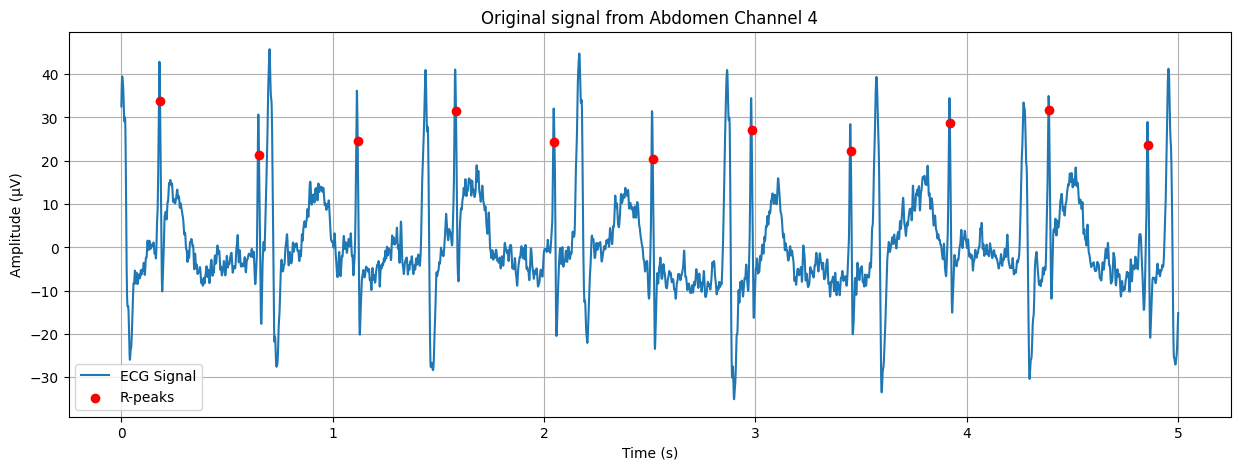

In [16]:
plot_signal(abdomen_segment_4, time_segment_4, onsets_4, onsets_values_4, title="Original signal from Abdomen Channel 4")

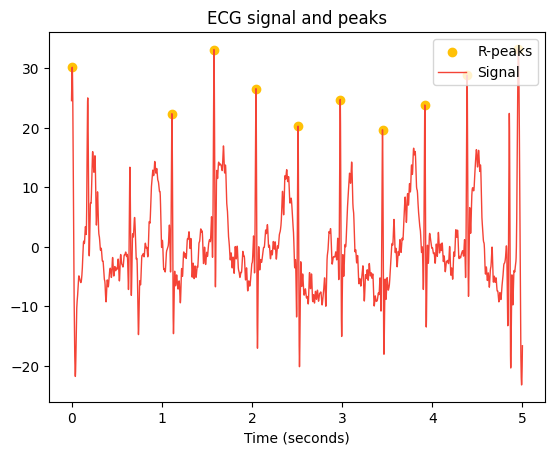

In [17]:
_, _ = nk.ecg_peaks(fecg, sampling_rate=1000, correct_artifacts=True, method="emrich2023", show=True)

## Signal quality (test)

We can also assess the quality of a signal in a quantitative way

In [18]:
abdomen_signals = [
    abdomen_segment_1,
    abdomen_segment_2,
    abdomen_segment_3,
    abdomen_segment_4
]

best_signals = []
for signal in abdomen_signals:
    best_cvp, best_signal, signals_quality = analyze_signal_quality(signal)
    print(f"Best CVP: {best_cvp} with quality scores: {np.argmax(signals_quality)}")
    best_signals.append(best_signal)

Best CVP: 75 with quality scores: 1
Best CVP: 95 with quality scores: 5
Best CVP: 95 with quality scores: 5
Best CVP: 70 with quality scores: 0


## Opzione A: concatenazione e SVD classica

In [19]:
L = 625*2
H1 = hankel(abdomen_segment_1[:L], abdomen_segment_1[L-1:])
H2 = hankel(abdomen_segment_2[:L], abdomen_segment_2[L-1:])
H3 = hankel(abdomen_segment_3[:L], abdomen_segment_3[L-1:])
H4 = hankel(abdomen_segment_4[:L], abdomen_segment_4[L-1:])

abdomen_signals = np.array([H1, H2, H3, H4])
abdomen_signals.shape

(4, 1250, 3751)

Selected components:
 - mECG: 1..36
 - fECG: 37..82
 - Noise: >82


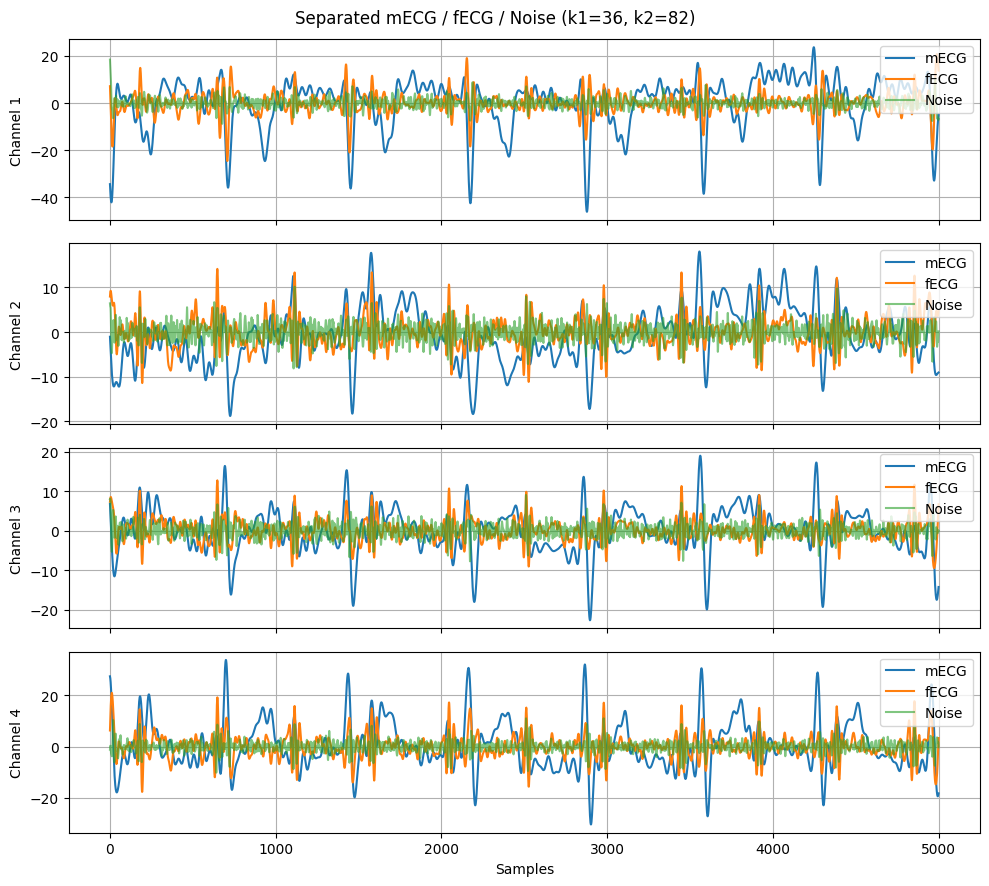

In [20]:
# Concatenate 4 Hankel matrices horizontally
H = np.hstack((H1, H2, H3, H4))
L, K = H1.shape

U, s, Vt = np.linalg.svd(H, full_matrices=False)

# Calculate explained variance for each singular value
var_explained = s**2 / np.sum(s**2)
cumulative_var = np.cumsum(var_explained)  # Cumulative explained variance

# Select the number of components to extract for mECG and fECG
k1 = np.argmax(cumulative_var >= 0.75) + 1
k2 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Selected components:")
print(f" - mECG: 1..{k1}")
print(f" - fECG: {k1+1}..{k2}")
print(f" - Noise: >{k2}")

# Partial reconstructions for mECG, fECG, and noise
H_mecg = U[:, :k1] @ np.diag(s[:k1]) @ Vt[:k1, :] 
H_fecg = U[:, k1:k2] @ np.diag(s[k1:k2]) @ Vt[k1:k2, :]
H_noise = U[:, k2:] @ np.diag(s[k2:]) @ Vt[k2:, :]

# Function to perform diagonal averaging on a Hankel matrix
def diagonal_averaging(H):
    L, K = H.shape
    N = L + K - 1  # Length of the reconstructed signal
    x_rec = np.zeros(N)  # Initialize the reconstructed signal
    counts = np.zeros(N)  # Initialize the counts for averaging
    for i in range(L):
        for j in range(K):
            x_rec[i + j] += H[i, j]  # Sum values along anti-diagonals
            counts[i + j] += 1  # Count the number of contributions
    return x_rec / counts  # Average the values

# Function to reconstruct signals for each channel
def reconstruct_channels(H_block):
    reconstructed = []
    for c in range(4):  # Iterate over 4 channels
        start_col = c * K
        end_col = (c + 1) * K
        Hc = H_block[:, start_col:end_col]  # Extract the Hankel matrix for the channel
        x_rec = diagonal_averaging(Hc)  # Perform diagonal averaging
        reconstructed.append(x_rec)
    return reconstructed

mECG_signals = reconstruct_channels(H_mecg)
fECG_signals = reconstruct_channels(H_fecg)
noise_signals = reconstruct_channels(H_noise)

fig, axs = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
for c in range(4):  # Iterate over 4 channels
    axs[c].plot(mECG_signals[c], color='C0', label='mECG')
    axs[c].plot(fECG_signals[c], color='C1', label='fECG')
    axs[c].plot(noise_signals[c], color='C2', alpha=0.6, label='Noise')
    axs[c].legend(loc='upper right')
    axs[c].grid(True)
    axs[c].set_ylabel(f'Channel {c+1}')

axs[-1].set_xlabel('Samples')
plt.suptitle(f'Separated mECG / fECG / Noise (k1={k1}, k2={k2})')
plt.tight_layout()
plt.show()

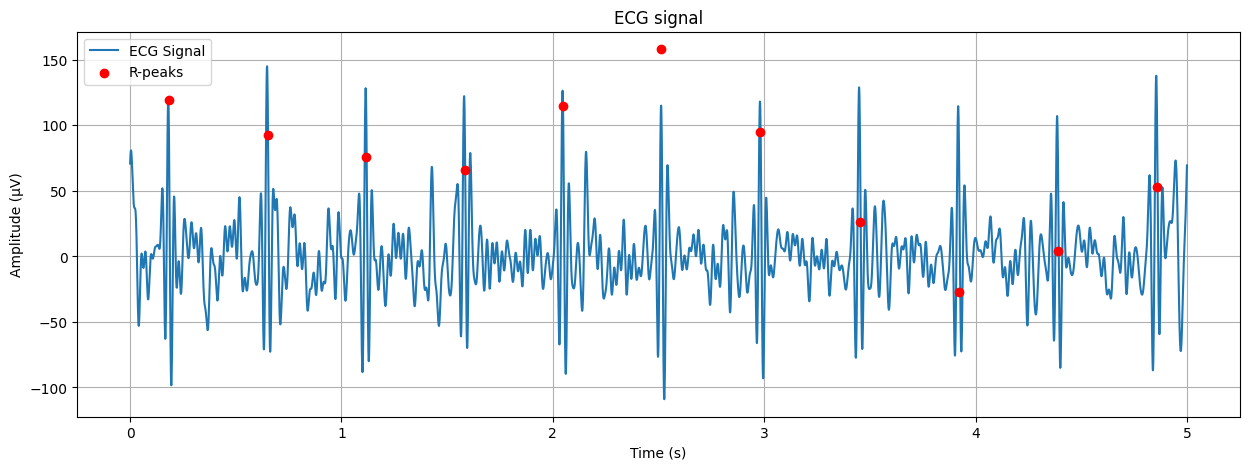

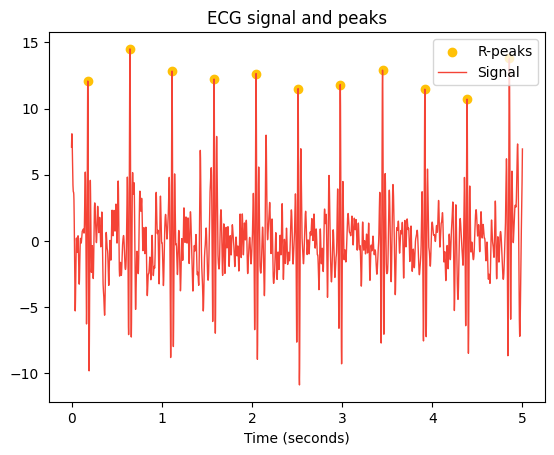

In [21]:
# mean and weighted combination
mECG_mean = np.mean(np.array(mECG_signals), axis=0)
fECG_mean = np.mean(np.array(fECG_signals), axis=0)
noise_mean = np.mean(np.array(noise_signals), axis=0)

quality = np.array([0.57, 0.50, 0.59, 0.74])
weights = quality / np.sum(quality)
mECG_combined = np.sum(np.array(mECG_signals) * np.array(weights)[:, None], axis=0)
fECG_combined = np.sum(np.array(fECG_signals) * np.array(weights)[:, None], axis=0)
noise_combined = np.sum(np.array(noise_signals) * np.array(weights)[:, None], axis=0)

time = np.linspace(0, len(mECG_mean)/1000, len(mECG_mean))  # fs = 1000 Hz

plot_signal(fECG_combined*10, time, onsets=onsets, onsets_values=onsets_values, title="ECG signal")
_, _ = nk.ecg_peaks(fECG_combined, sampling_rate=1000, correct_artifacts=True, method="emrich2023", show=True)

## Opzione B: stack come tensore e decomposizione tensoriale

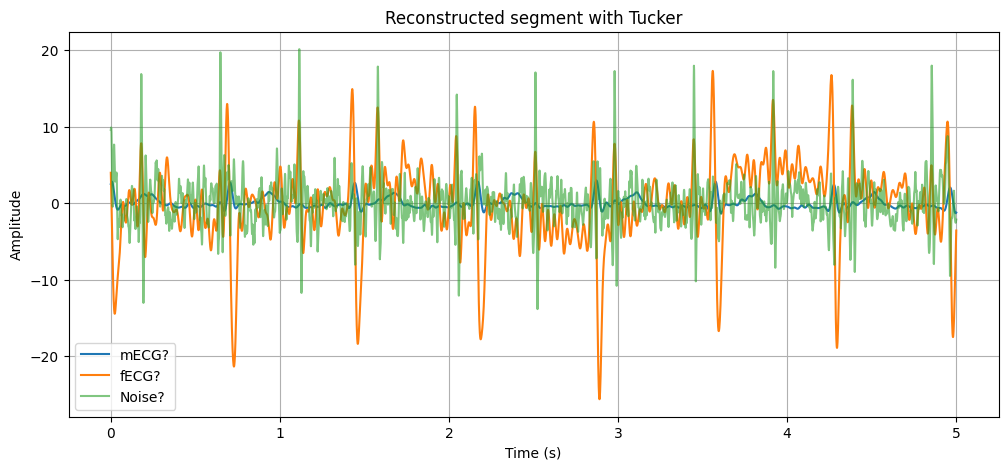

In [22]:
# Stack the Hankel matrices for all 4 channels along the third dimension to form a tensor
H_tensor = np.stack([H1, H2, H3, H4], axis=2)  # shape (L, K, 4)
L, K, C = H_tensor.shape  # Extract dimensions: L (rows), K (columns), C (channels)

quality = np.array([0.57, 0.50, 0.59, 0.74])  # Quality scores for the 4 channels
weights = quality / np.sum(quality)  # Normalize to ensure the sum of weights equals 1

# Tucker decomposition to separate the tensor into a core tensor and factor matrices
rank = [min(50, L), min(50, K), 4]
core, factors = tucker(H_tensor, rank=rank)
U_L, U_K, U_C = factors

S_mecg = np.zeros_like(core)
S_mecg[:, :, 0] = core[:, :, 0]  # Assign the first component to mECG

S_fecg = np.zeros_like(core)
S_fecg[:, :, 1:] = core[:, :, 1:]  # Assign the remaining components to fECG

# Reconstruct partial tensors for mECG, fECG, and noise
H_mecg = tl.tucker_to_tensor((S_mecg, factors))
H_fecg = tl.tucker_to_tensor((S_fecg, factors))
H_noise = H_tensor - (H_mecg + H_fecg)

# Function for diagonal averaging to reconstruct a signal from a Hankel matrix
def diagonal_averaging(H):
    L, K = H.shape
    N = L + K - 1
    x_rec = np.zeros(N)
    counts = np.zeros(N)
    for i in range(L):
        for j in range(K):
            x_rec[i + j] += H[i, j]  # Sum values along anti-diagonals
            counts[i + j] += 1  # Count the number of contributions
    return x_rec / counts  # Average the values

# Function to reconstruct signals for each channel from a tensor
def reconstruct_channels(H_block):
    L, K, C = H_block.shape
    reconstructed = []
    for c in range(C):  # Iterate over channels
        x_rec = diagonal_averaging(H_block[:, :, c])  # Perform diagonal averaging
        reconstructed.append(x_rec)
    return reconstructed

# Reconstruct signals for mECG, fECG, and noise
mECG_signals = reconstruct_channels(H_mecg)
fECG_signals = reconstruct_channels(H_fecg)
noise_signals = reconstruct_channels(H_noise)

# Weighted combination of signals from all channels
mECG_combined = np.sum(np.array(mECG_signals) * weights[:, None], axis=0)
fECG_combined = np.sum(np.array(fECG_signals) * weights[:, None], axis=0)
noise_combined = np.sum(np.array(noise_signals) * weights[:, None], axis=0)

time = np.linspace(0, len(mECG_combined)/1000, len(mECG_combined))  # Time in seconds

# Plot the results
plt.figure(figsize=(12, 5))
plt.plot(time, mECG_combined, label='mECG?', color='C0')  # Plot mECG?
plt.plot(time, fECG_combined, label='fECG?', color='C1')  # Plot fECG?
plt.plot(time, noise_combined, label='Noise?', color='C2', alpha=0.6)  # Plot noise?
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Reconstructed segment with Tucker')
plt.legend()
plt.grid(True)
plt.show()


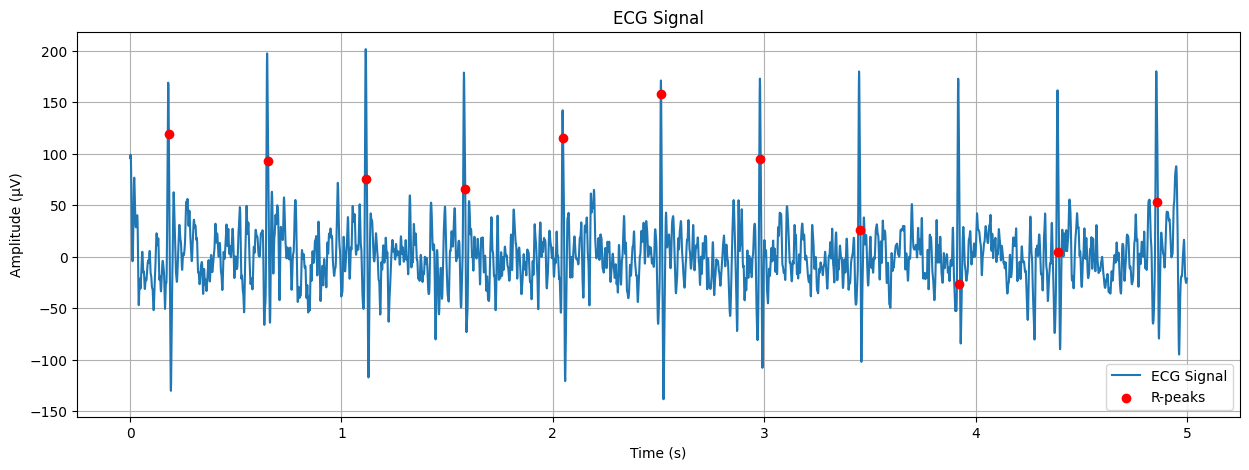

In [23]:
plot_signal(noise_combined*10, time, onsets=onsets, onsets_values=onsets_values, title="ECG Signal")

## Window simulation

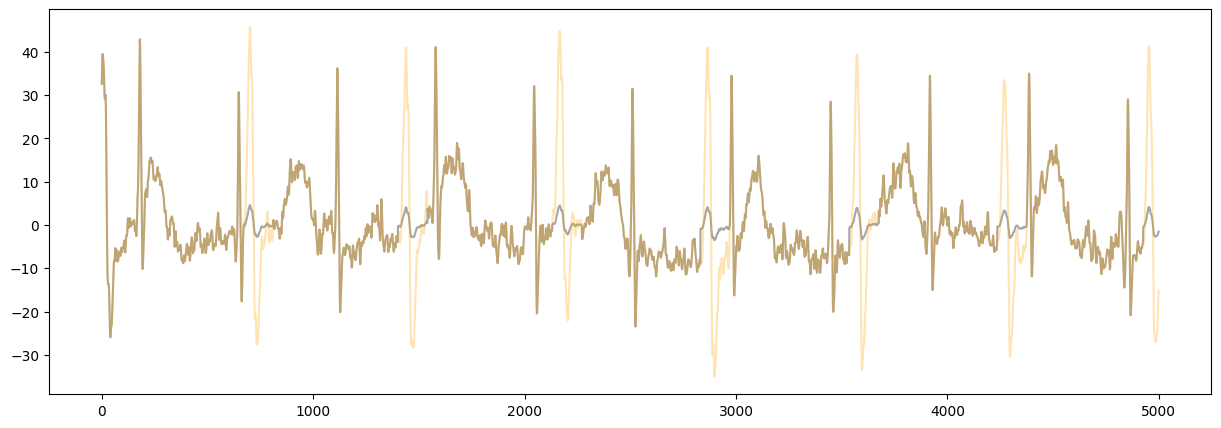

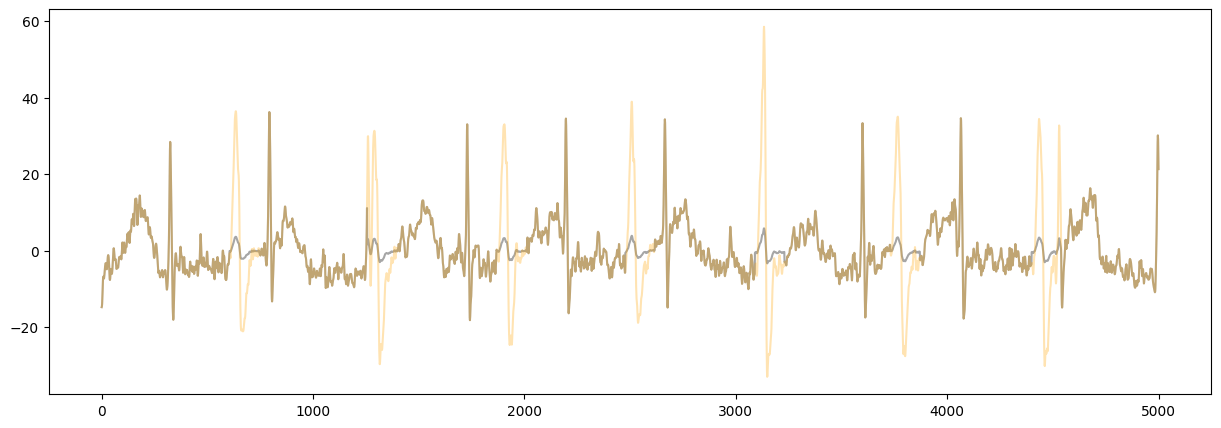

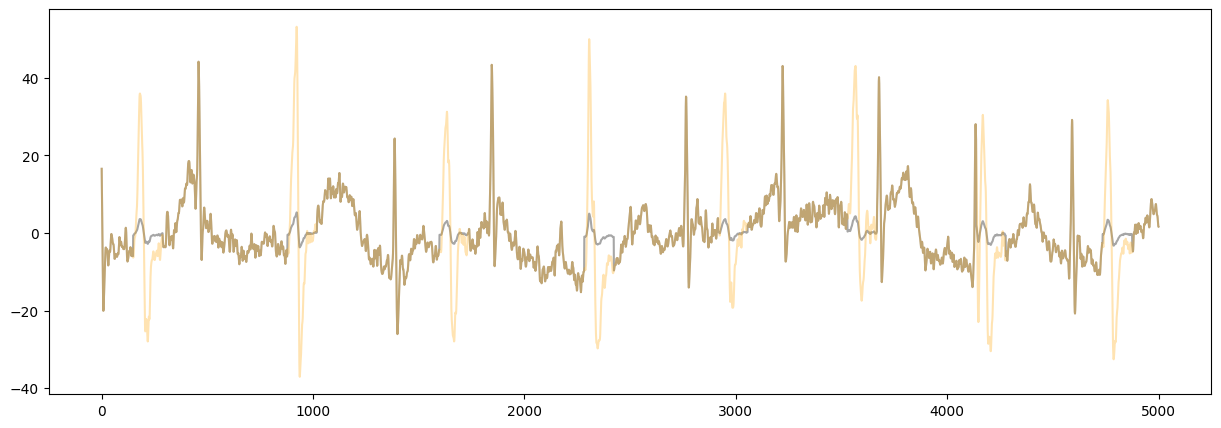

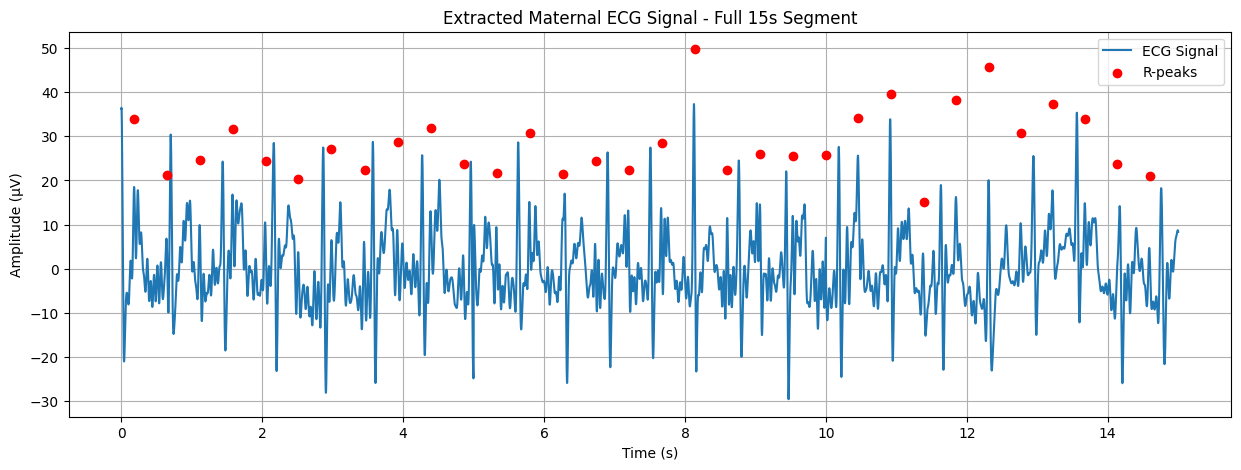

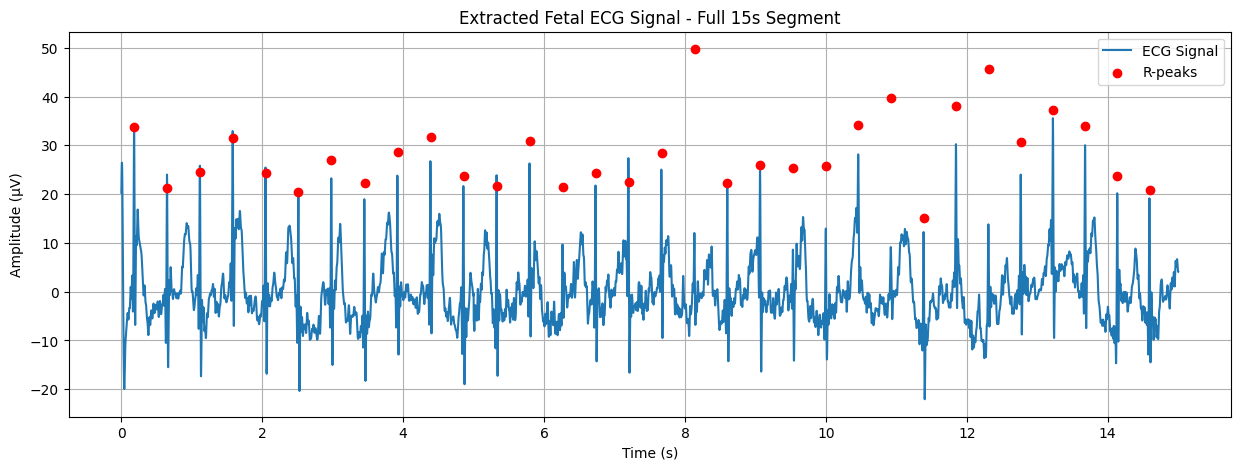

In [24]:
start_time = 0
end_time = 5

segment_1, time_segment_1, onsets_1, onsets_values_1 = get_signal_segment(ch_number=4, start_time=start_time, end_time=end_time)
segment_2, time_segment_2, onsets_2, onsets_values_2 = get_signal_segment(ch_number=4, start_time=start_time+5, end_time=end_time+5)
segment_3, time_segment_3, onsets_3, onsets_values_3 = get_signal_segment(ch_number=4, start_time=start_time+10, end_time=end_time+10)

mecg_1 = hankelize_and_extract(segment_1, window_size=625*2, cvp=70)
mecg_signals_1, mecg_info_1 = nk.ecg_peaks(-mecg_1, sampling_rate=1000, correct_artifacts=True, method="emrich2023")
mecg_peaks_1 = mecg_info_1['ECG_R_Peaks']
residual_signal_1 = interpolate_peaks(segment_1, peaks=mecg_peaks_1, show=True)
fecg_1 = hankelize_and_extract(residual_signal_1, window_size=454*2, cvp=90)

mecg_2 = hankelize_and_extract(segment_2, window_size=625*2, cvp=70)
mecg_signals_2, mecg_info_2 = nk.ecg_peaks(-mecg_2, sampling_rate=1000, correct_artifacts=True, method="emrich2023")
mecg_peaks_2 = mecg_info_2['ECG_R_Peaks']
residual_signal_2 = interpolate_peaks(segment_2, peaks=mecg_peaks_2, show=True)
fecg_2 = hankelize_and_extract(residual_signal_2, window_size=454*2, cvp=90)

mecg_3 = hankelize_and_extract(segment_3, window_size=625*2, cvp=70)
mecg_signals_3, mecg_info_3 = nk.ecg_peaks(-mecg_3, sampling_rate=1000, correct_artifacts=True, method="emrich2023")
mecg_peaks_3 = mecg_info_3['ECG_R_Peaks']
residual_signal_3 = interpolate_peaks(segment_3, peaks=mecg_peaks_3, show=True)
fecg_3 = hankelize_and_extract(residual_signal_3, window_size=454*2, cvp=90)

fecg = np.concatenate((fecg_1, fecg_2, fecg_3))
time = np.concatenate((time_segment_1, time_segment_2, time_segment_3))
onsets = np.concatenate((onsets_1, onsets_2, onsets_3))
onsets_values = np.concatenate((onsets_values_1, onsets_values_2, onsets_values_3))

mecg = np.concatenate((mecg_1, mecg_2, mecg_3))

plot_signal(mecg, time, onsets, onsets_values, title="Extracted Maternal ECG Signal - Full 15s Segment")
plot_signal(fecg, time, onsets, onsets_values, title="Extracted Fetal ECG Signal - Full 15s Segment")

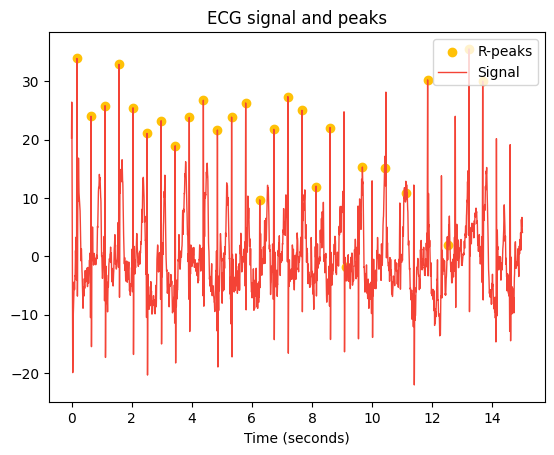

In [25]:
_, _ = nk.ecg_peaks(fecg, sampling_rate=1000, correct_artifacts=True, method="emrich2023", show=True)

## Full window extraction

In [26]:
import numpy as np
import neurokit2 as nk
from scipy.signal.windows import hann

start_time = 0
end_time = 5
overlap = 0.5  # overlap di 0.5 secondi
segment_length = end_time - start_time

channel = 4
sampling_rate = edf.getSampleFrequency(channel)
signal_full = edf.readSignal(channel)
total_duration = len(signal_full) / sampling_rate

# preparazione array finali
full_length = int(total_duration * sampling_rate)
combined_mecg = np.zeros(full_length)
combined_fecg = np.zeros(full_length)
weights_m = np.zeros(full_length)
weights_f = np.zeros(full_length)

mecgs = []
fecgs = []
times = []
onsets_list = []
onsets_values_list = []

curr_start = start_time
while curr_start < total_duration:
    curr_end = min(curr_start + segment_length, total_duration)
    print(f"Processing segment from {curr_start:.1f} to {curr_end:.1f} seconds...")

    seg, tseg, onsets_seg, onsets_values_seg = get_signal_segment(
        ch_number=channel, start_time=curr_start, end_time=curr_end
    )

    # estrazione mECG
    mecg = hankelize_and_extract(seg, window_size=625 * 2, cvp=70)
    if mecg is None or len(mecg) == 0 or np.all(np.isnan(mecg)):
        print(f"Skipping segment {curr_start:.1f}-{curr_end:.1f}: invalid mECG")
        curr_start += segment_length - overlap
        continue

    # rilevamento picchi materni
    mecg = np.nan_to_num(mecg)
    mecg -= np.mean(mecg)
    mecg /= (np.std(mecg) + 1e-8)
    try:
        _, mecg_info = nk.ecg_peaks(-mecg, sampling_rate=1000, correct_artifacts=True, method="neurokit")
        mecg_peaks = mecg_info["ECG_R_Peaks"]
    except Exception as e:
        print(f"Peak detection failed ({curr_start:.1f}-{curr_end:.1f}): {e}")
        curr_start += segment_length - overlap
        continue

    residual_signal = interpolate_peaks(seg, peaks=mecg_peaks, show=False)
    fecg = hankelize_and_extract(residual_signal, window_size=454 * 2, cvp=90)
    if fecg is None or len(fecg) == 0 or np.all(np.isnan(fecg)):
        print(f"Skipping fECG at {curr_start:.1f}-{curr_end:.1f}: invalid extraction")
        curr_start += segment_length - overlap
        continue

    mecgs.append(mecg)
    fecgs.append(fecg)
    times.append(tseg)
    onsets_list.append(onsets_seg)
    onsets_values_list.append(onsets_values_seg)

    # fusione con finestra di Hann (da capire se va bene)
    window = hann(len(mecg)) # crea la finestra di Hann lunga quanto il segmento
    start_idx = int(curr_start * sampling_rate)
    end_idx = min(start_idx + len(window), full_length)
    w = window[: end_idx - start_idx] # adatta la finestra se siamo alla fine del segnale

    combined_mecg[start_idx:end_idx] += mecg[: len(w)] * w
    combined_fecg[start_idx:end_idx] += fecg[: len(w)] * w
    weights_m[start_idx:end_idx] += w
    weights_f[start_idx:end_idx] += w

    curr_start += segment_length - overlap  # avanza con overlap

# normalizzazione (compensazione delle somme pesate)
combined_mecg /= np.maximum(weights_m, 1e-8)
combined_fecg /= np.maximum(weights_f, 1e-8)

# costruzione finali (per compatibilità con codice esistente)
full_mecg = combined_mecg
full_fecg = combined_fecg
full_time = np.arange(full_length) / sampling_rate
full_onsets = np.concatenate(onsets_list) if any(len(x) > 0 for x in onsets_list) else np.array([])
full_onsets_values = np.concatenate(onsets_values_list) if any(len(x) > 0 for x in onsets_values_list) else np.array([])

np.save("full_mecg.npy", full_mecg)
np.save("full_fecg.npy", full_fecg)
np.save("full_time.npy", full_time)
np.save("full_onsets.npy", full_onsets)
np.save("full_onsets_values.npy", full_onsets_values)

Processing segment from 0.0 to 5.0 seconds...
Processing segment from 4.5 to 9.5 seconds...
Processing segment from 9.0 to 14.0 seconds...
Processing segment from 13.5 to 18.5 seconds...
Processing segment from 18.0 to 23.0 seconds...
Processing segment from 22.5 to 27.5 seconds...
Processing segment from 27.0 to 32.0 seconds...
Processing segment from 31.5 to 36.5 seconds...
Processing segment from 36.0 to 41.0 seconds...
Processing segment from 40.5 to 45.5 seconds...
Processing segment from 45.0 to 50.0 seconds...
Processing segment from 49.5 to 54.5 seconds...


c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Processing segment from 54.0 to 59.0 seconds...


c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Processing segment from 58.5 to 63.5 seconds...


...

Processing segment from 207.0 to 212.0 seconds...


c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Processing segment from 211.5 to 216.5 seconds...


c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Processing segment from 216.0 to 221.0 seconds...
Processing segment from 220.5 to 225.5 seconds...
Processing segment from 225.0 to 230.0 seconds...
Processing segment from 229.5 to 234.5 seconds...
Processing segment from 234.0 to 239.0 seconds...
Processing segment from 238.5 to 243.5 seconds...
Processing segment from 243.0 to 248.0 seconds...
Processing segment from 247.5 to 252.5 seconds...
Processing segment from 252.0 to 257.0 seconds...
Processing segment from 256.5 to 261.5 seconds...
Processing segment from 261.0 to 266.0 seconds...
Processing segment from 265.5 to 270.5 seconds...
Processing segment from 270.0 to 275.0 seconds...
Processing segment from 274.5 to 279.5 seconds...
Processing segment from 279.0 to 284.0 seconds...
Processing segment from 283.5 to 288.5 seconds...
Processing segment from 288.0 to 293.0 seconds...
Processing segment from 292.5 to 297.5 seconds...
Processing segment from 297.0 to 300.0 seconds...


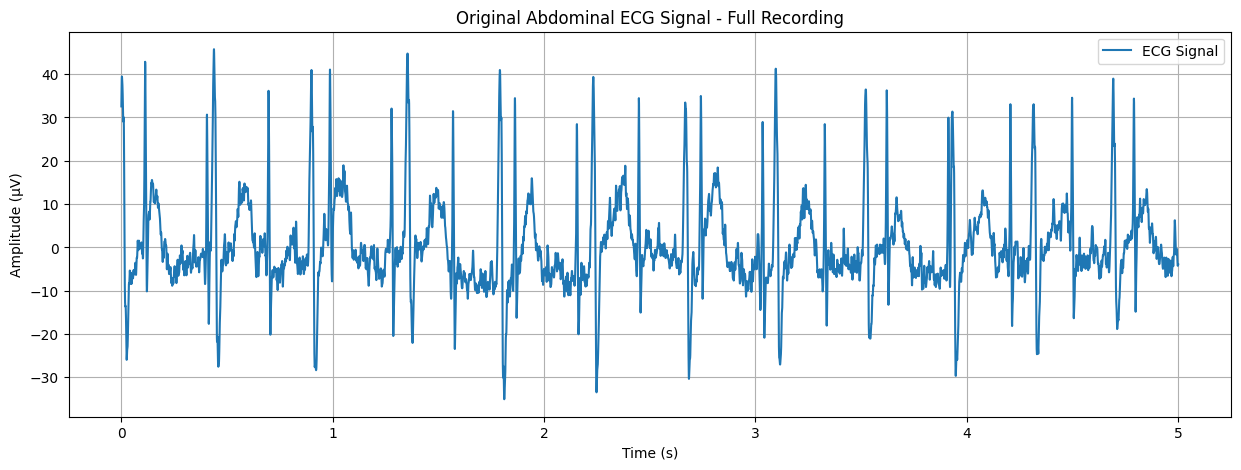

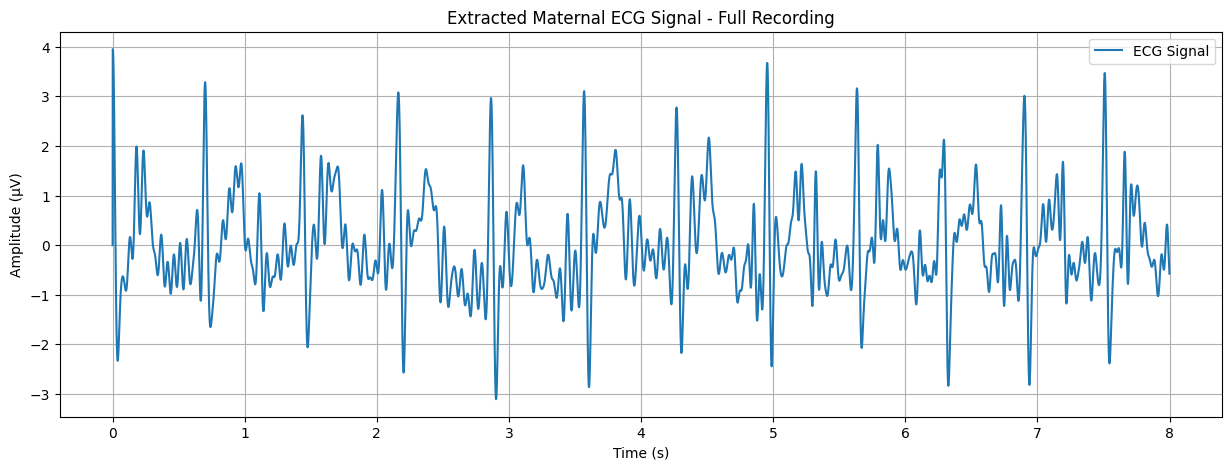

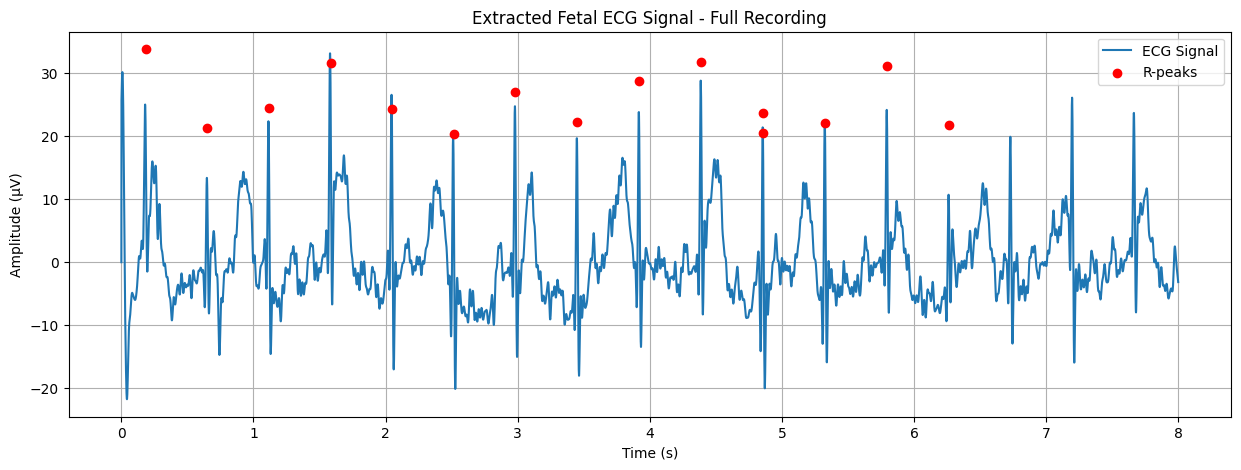

In [27]:
plot_signal(signal_full[:8000], np.linspace(0, 5, 8000),
            title="Original Abdominal ECG Signal - Full Recording")
plot_signal(full_mecg[:8000], full_time[:8000],
            title="Extracted Maternal ECG Signal - Full Recording")
plot_signal(full_fecg[:8000], full_time[:8000], full_onsets[:15], full_onsets_values[:15],
            title="Extracted Fetal ECG Signal - Full Recording")

## Full window extraction with Tucker

In [ ]:
import numpy as np
import tensorly as tl
from tensorly.decomposition import tucker
from scipy.signal.windows import hann
from loguru import logger

fs = 1000  # frequenza di campionamento
segment_length = 5.0
overlap = 0.5
step = segment_length - overlap
channels = [1, 2, 3, 4]
quality = np.array([0.57, 0.50, 0.59, 0.74])
weights = quality / np.sum(quality)

channel = 4
sampling_rate = edf.getSampleFrequency(channel)
signal_full = edf.readSignal(channel)[:60000]
total_duration = len(signal_full) / sampling_rate

full_length = int(total_duration * fs)
full_mecg = np.zeros(full_length)
full_fecg = np.zeros(full_length)
full_noise = np.zeros(full_length)
weights_final = np.zeros(full_length)

curr_start = 0
while curr_start < total_duration:
    print(f"Processing segment from {curr_start:.1f} to {min(curr_start + segment_length, total_duration):.1f} seconds...")
    curr_end = min(curr_start + segment_length, total_duration)

    # estrai segmenti dai canali
    logger.info(f"Extracting signal segments from {curr_start:.1f}s to {curr_end:.1f}s")
    segments = []
    for ch in channels:
        seg, _, _, _ = get_signal_segment(ch_number=ch, start_time=curr_start, end_time=curr_end)
        seg = np.nan_to_num(seg)
        segments.append(seg)

    # costruzione matrici Hankel
    logger.info("Constructing Hankel matrices")
    H_list = []
    for seg in segments:
        L = 625*2  # esempio
        K = len(seg) - L + 1
        H = np.column_stack([seg[i:i+L] for i in range(K)])
        H_list.append(H)

    H_tensor = np.stack(H_list, axis=2)
    L, K, C = H_tensor.shape

    # Tucker decomposition
    logger.info("Performing Tucker decomposition")
    rank = [min(50,L), min(50,K), C]
    core, factors = tucker(H_tensor, rank=rank, tol=1e-1)
    U_L, U_K, U_C = factors

    # separazione componenti
    logger.info("Separating components")
    S_mecg = np.zeros_like(core)
    S_mecg[:,:,0] = core[:,:,0]

    S_fecg = np.zeros_like(core)
    S_fecg[:,:,1:] = core[:,:,1:]

    H_mecg = tl.tucker_to_tensor((S_mecg, factors))
    H_fecg = tl.tucker_to_tensor((S_fecg, factors))
    H_noise = H_tensor - (H_mecg + H_fecg)

    # diagonal averaging
    def diagonal_averaging(H):
        L, K = H.shape
        N = L + K - 1
        x_rec = np.zeros(N)
        counts = np.zeros(N)
        for i in range(L):
            for j in range(K):
                x_rec[i+j] += H[i,j]
                counts[i+j] += 1
        return x_rec / counts

    def reconstruct_channels(H_block):
        L, K, C = H_block.shape
        rec = []
        for c in range(C):
            rec.append(diagonal_averaging(H_block[:,:,c]))
        return rec

    logger.info("Reconstructing signals for each component")
    mECG_signals = reconstruct_channels(H_mecg)
    fECG_signals = reconstruct_channels(H_fecg)
    noise_signals = reconstruct_channels(H_noise)

    # weighted combination
    mECG_seg = np.sum(np.array(mECG_signals) * weights[:,None], axis=0)
    fECG_seg = np.sum(np.array(fECG_signals) * weights[:,None], axis=0)
    noise_seg = np.sum(np.array(noise_signals) * weights[:,None], axis=0)

    # finestra di Hann e fusione
    logger.info("Applying Hann window and merging segments")
    window = hann(len(mECG_seg))
    start_idx = int(curr_start*fs)
    end_idx = min(start_idx + len(window), full_length)
    w = window[:end_idx-start_idx]

    full_mecg[start_idx:end_idx] += mECG_seg[:len(w)] * w
    full_fecg[start_idx:end_idx] += fECG_seg[:len(w)] * w
    full_noise[start_idx:end_idx] += noise_seg[:len(w)] * w
    weights_final[start_idx:end_idx] += w

    curr_start += step

# normalizzazione finale
full_mecg /= np.maximum(weights_final, 1e-8)
full_fecg /= np.maximum(weights_final, 1e-8)
full_noise /= np.maximum(weights_final, 1e-8)

np.save("full_mecg_tucker.npy", full_mecg)
np.save("full_fecg_tucker.npy", full_fecg)
np.save("full_noise_tucker.npy", full_noise)

# ci mette 15 minuti circa per estrarre i primi 60 secondi di segnale
# il risultato è migliore di quello senza tucker

2025-10-30 10:39:51.774 | INFO     | __main__:<module>:32 - Extracting signal segments from 0.0s to 5.0s


2025-10-30 10:39:51.828 | INFO     | __main__:<module>:40 - Constructing Hankel matrices


Processing segment from 0.0 to 5.0 seconds...


2025-10-30 10:39:51.999 | INFO     | __main__:<module>:52 - Performing Tucker decomposition
2025-10-30 10:40:23.771 | INFO     | __main__:<module>:58 - Separating components
2025-10-30 10:40:24.329 | INFO     | __main__:<module>:88 - Reconstructing signals for each component


KeyboardInterrupt: 

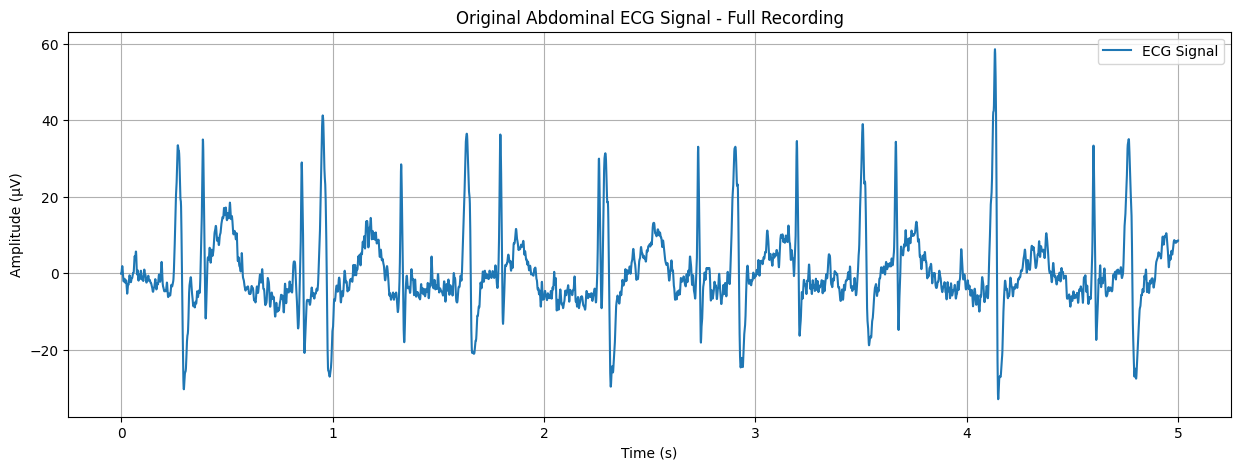

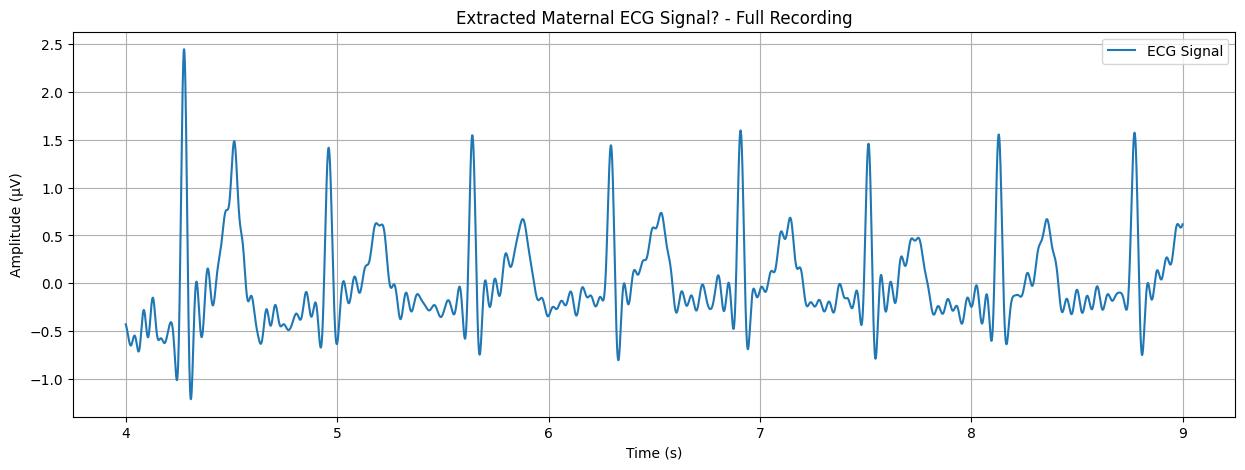

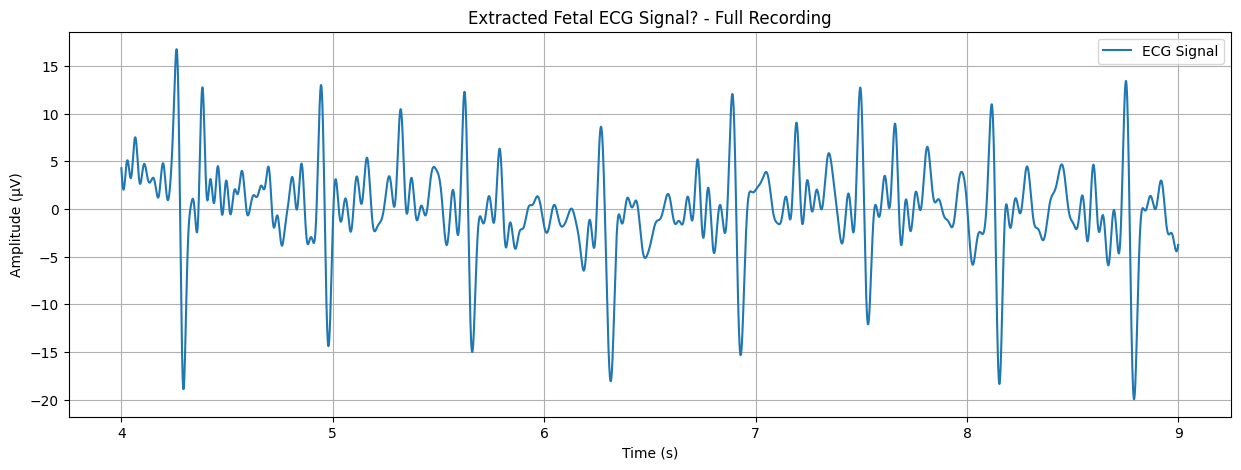

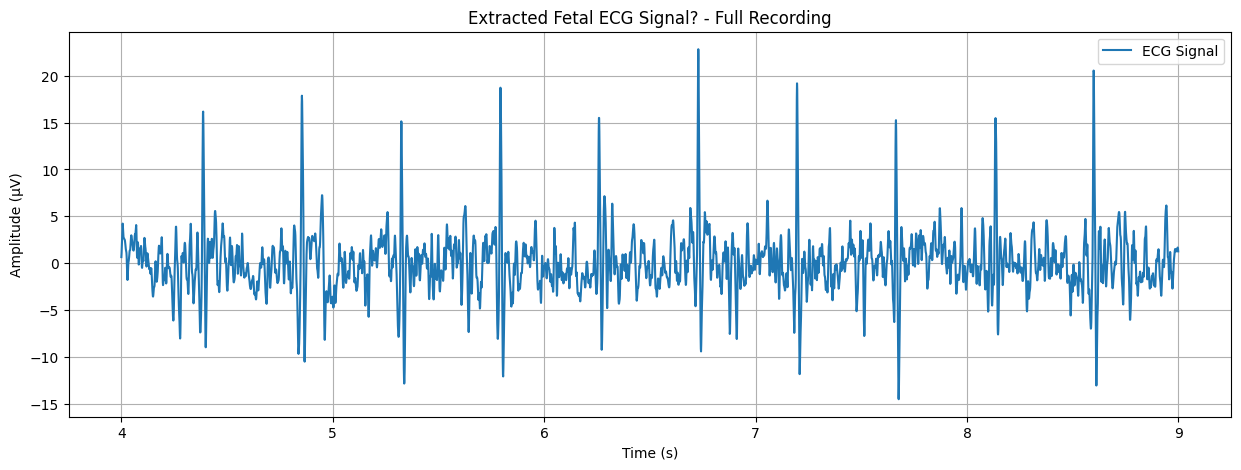

In [8]:
full_time = np.arange(full_length) / sampling_rate

# plot dei primi 15.000 campioni (es. primi 15 s se fs=1000 Hz)
plot_signal(signal_full[4000:9000], np.linspace(0, 5, 5000),
            title="Original Abdominal ECG Signal - Full Recording")
plot_signal(full_mecg[4000:9000], full_time[4000:9000],
            title="Extracted Maternal ECG Signal? - Full Recording")
plot_signal(full_fecg[4000:9000], full_time[4000:9000],
            title="Extracted Fetal ECG Signal? - Full Recording")
plot_signal(full_noise[4000:9000], full_time[4000:9000],
            title="Extracted Fetal ECG Signal? - Full Recording")


In [15]:
import torch
import numpy as np
from scipy.signal.windows import hann
from loguru import logger
import tensorly as tl

# Ensure CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

tl.set_backend('pytorch')

# Move data to CUDA
fs = 1000  # frequenza di campionamento
segment_length = 5.0
overlap = 0.5
step = segment_length - overlap
channels = [1, 2, 3, 4]
quality = np.array([0.57, 0.50, 0.59, 0.74])
weights = torch.tensor(quality / np.sum(quality), device=device, dtype=torch.float32)

# Assuming `signal_full` and other arrays are numpy arrays
signal_full = edf.readSignal(4)[:60000]
sampling_rate = edf.getSampleFrequency(4)
total_duration = len(signal_full) / sampling_rate
signal_full = torch.tensor(signal_full, device=device, dtype=torch.float32)
full_mecg = torch.zeros_like(signal_full, device=device)
full_fecg = torch.zeros_like(signal_full, device=device)
full_noise = torch.zeros_like(signal_full, device=device)
weights_final = torch.zeros_like(signal_full, device=device)

curr_start = 0
while curr_start < total_duration:
    logger.info(f"Processing segment from {curr_start:.1f} to {min(curr_start + segment_length, total_duration):.1f} seconds...")
    curr_end = min(curr_start + segment_length, total_duration)

    # Extract signal segments from channels
    segments = []
    for ch in channels:
        result = get_signal_segment(ch_number=ch, start_time=curr_start, end_time=curr_end)
        if isinstance(result, tuple) and len(result) >= 1:
            seg = result[0]
        else:
            raise ValueError("Unexpected return value from get_signal_segment. Expected at least one value.")
        seg = np.nan_to_num(seg)
        segments.append(torch.tensor(seg, device=device, dtype=torch.float32))

    # Construct Hankel matrices
    logger.info("Constructing Hankel matrices")
    H_list = []
    for seg in segments:
        L = 625 * 2  # Example
        K = len(seg) - L + 1
        H = torch.stack([seg[i:i + L] for i in range(K)], dim=1)
        H_list.append(H)

    H_tensor = torch.stack(H_list, dim=2).to(device)
    L, K, C = H_tensor.shape

    # Tucker decomposition (use PyTorch or a library that supports GPU)
    logger.info("Performing Tucker decomposition")
    rank = [min(50, L), min(50, K), C]
    core, factors = tucker(H_tensor, rank=rank, tol=1e-1)

    # Separate components
    logger.info("Separating components")
    S_mecg = torch.zeros_like(core, device=device)
    S_mecg[:, :, 0] = core[:, :, 0]

    S_fecg = torch.zeros_like(core, device=device)
    S_fecg[:, :, 1:] = core[:, :, 1:]

    H_mecg = tl.tucker_to_tensor((S_mecg, factors))  # Replace with GPU-compatible reconstruction
    H_fecg = tl.tucker_to_tensor((S_fecg, factors))
    H_noise = H_tensor - (H_mecg + H_fecg)

    import torch

    def diagonal_averaging(H):
        """
        H: tensor 2D di forma (L, K) su GPU
        Restituisce x_rec di forma (L+K-1)
        """
        L, K = H.shape
        N = L + K - 1

        # Creiamo gli indici diagonali
        i = torch.arange(L, device=H.device).view(-1, 1)
        j = torch.arange(K, device=H.device).view(1, -1)
        diag_indices = i + j  # shape (L, K)

        # Flatten H e diag_indices
        H_flat = H.flatten()
        diag_flat = diag_indices.flatten()

        # Somma e conteggio usando scatter_add
        x_rec = torch.zeros(N, device=H.device).scatter_add_(0, diag_flat, H_flat)
        counts = torch.zeros(N, device=H.device).scatter_add_(0, diag_flat, torch.ones_like(H_flat))

        return x_rec / counts


    def reconstruct_channels(H_block):
        """
        H_block: tensor 3D di forma (L, K, C) su GPU
        Restituisce tensor 2D di forma (L+K-1, C)
        """
        L, K, C = H_block.shape
        # Applichiamo diagonal_averaging su ciascun canale usando comprehension e stack
        rec = torch.stack([diagonal_averaging(H_block[:, :, c]) for c in range(C)], dim=1)
        return rec


    logger.info("Reconstructing signals for each component")
    mECG_signals = reconstruct_channels(H_mecg)
    fECG_signals = reconstruct_channels(H_fecg)
    noise_signals = reconstruct_channels(H_noise)

    mECG_seg = torch.sum(mECG_signals * weights[None, :], dim=1)  # somma ponderata sui canali
    fECG_seg = torch.sum(fECG_signals * weights[None, :], dim=1)
    noise_seg = torch.sum(noise_signals * weights[None, :], dim=1)

    # Hann window and merging segments
    logger.info("Applying Hann window and merging segments")
    window = torch.tensor(hann(len(mECG_seg)), device=device, dtype=torch.float32)
    start_idx = int(curr_start * fs)
    end_idx = min(start_idx + len(window), full_mecg.size(0))
    w = window[:end_idx - start_idx]

    full_mecg[start_idx:end_idx] += mECG_seg[:len(w)] * w
    full_fecg[start_idx:end_idx] += fECG_seg[:len(w)] * w
    full_noise[start_idx:end_idx] += noise_seg[:len(w)] * w
    weights_final[start_idx:end_idx] += w

    curr_start += step

# Final normalization
full_mecg /= torch.maximum(weights_final, torch.tensor(1e-8, device=device))
full_fecg /= torch.maximum(weights_final, torch.tensor(1e-8, device=device))
full_noise /= torch.maximum(weights_final, torch.tensor(1e-8, device=device))

# Save results back to CPU
np.save("full_mecg_tucker.npy", full_mecg.cpu().numpy())
np.save("full_fecg_tucker.npy", full_fecg.cpu().numpy())
np.save("full_noise_tucker.npy", full_noise.cpu().numpy())


2025-10-30 16:19:02.696 | INFO     | __main__:<module>:9 - Using device: cuda
2025-10-30 16:19:02.712 | INFO     | __main__:<module>:34 - Processing segment from 0.0 to 5.0 seconds...
2025-10-30 16:19:02.776 | INFO     | __main__:<module>:49 - Constructing Hankel matrices
2025-10-30 16:19:02.848 | INFO     | __main__:<module>:61 - Performing Tucker decomposition
2025-10-30 16:19:10.815 | INFO     | __main__:<module>:66 - Separating components
2025-10-30 16:19:10.818 | INFO     | __main__:<module>:114 - Reconstructing signals for each component
2025-10-30 16:19:10.823 | INFO     | __main__:<module>:124 - Applying Hann window and merging segments
2025-10-30 16:19:10.835 | INFO     | __main__:<module>:34 - Processing segment from 4.5 to 9.5 seconds...
2025-10-30 16:19:10.892 | INFO     | __main__:<module>:49 - Constructing Hankel matrices
2025-10-30 16:19:10.952 | INFO     | __main__:<module>:61 - Performing Tucker decomposition
2025-10-30 16:19:18.527 | INFO     | __main__:<module>:66 - 

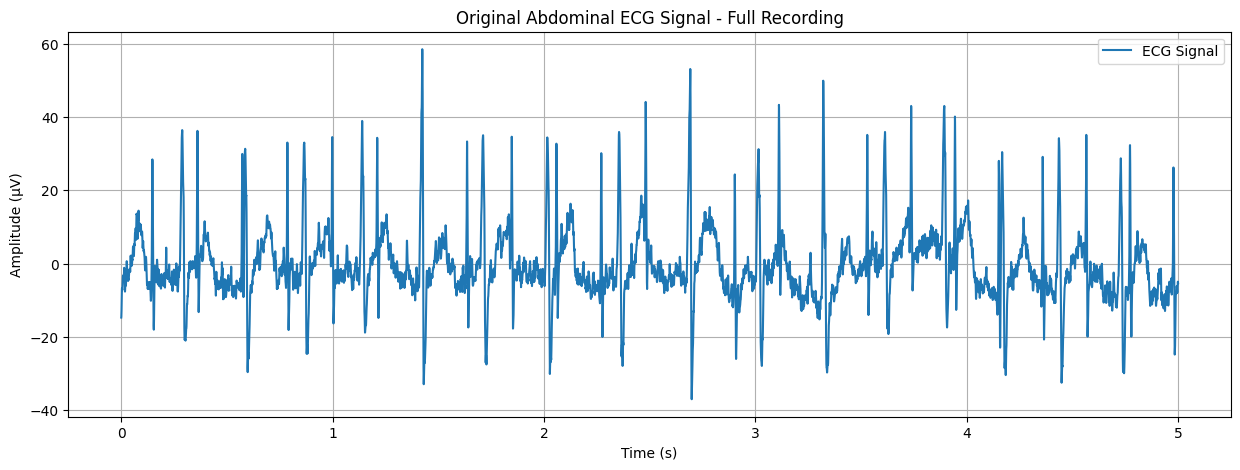

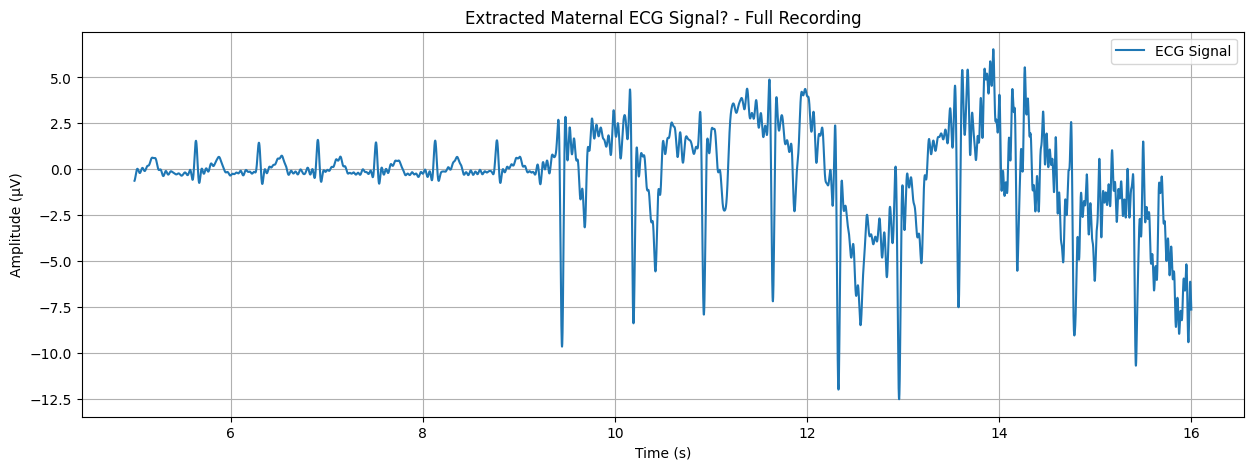

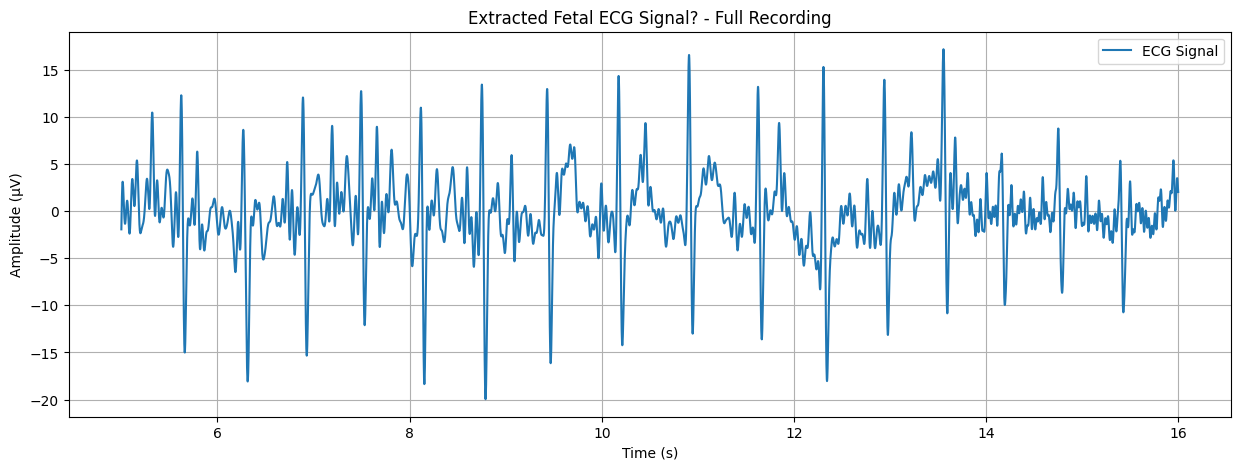

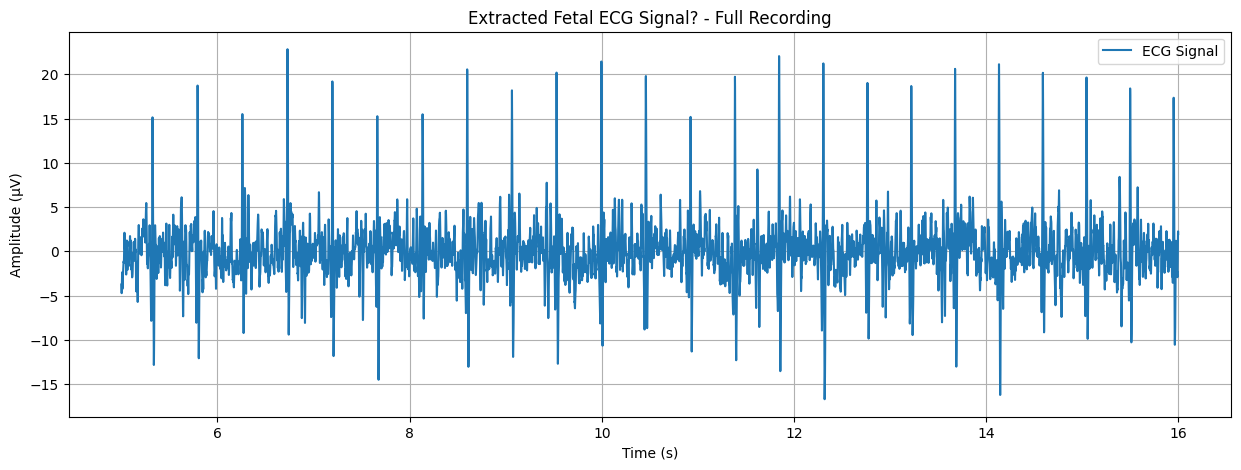

In [23]:
full_length = int(total_duration * fs)
full_time = np.arange(full_length) / sampling_rate

# plot dei primi 15.000 campioni (es. primi 15 s se fs=1000 Hz)
plot_signal(signal_full[5000:16000].cpu().numpy(), np.linspace(0, 5, 11000),
            title="Original Abdominal ECG Signal - Full Recording")
plot_signal(full_mecg[5000:16000].cpu().numpy(), full_time[5000:16000],
            title="Extracted Maternal ECG Signal? - Full Recording")
plot_signal(full_fecg[5000:16000].cpu().numpy(), full_time[5000:16000],
            title="Extracted Fetal ECG Signal? - Full Recording")
plot_signal(full_noise[5000:16000].cpu().numpy(), full_time[5000:16000],
            title="Extracted Fetal ECG Signal? - Full Recording")
